<a href="https://colab.research.google.com/github/joiepark/assignment_esaa/blob/main/YB%2011.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 군집화

## K-평균 알고리즘 이해
*   K-평균은 군집화(Clustering)에서 가장 일반적으로 사용되는 알고리즘이다. K-평균은 군집 중심점(centroid)이라는 특정한 임의의 지점을 선택해 해당 중심에 가장 가까운 포인트들을 선택하는 군집화 기법이다.
*   군집 중심점은 선택된 포인트의 평균 지점으로 이동하고 이동된 중심점에서 다시 가까운 포인트를 선택, 다시 중심점을 평균 지점으로 이동하는 프로세스를 반복적으로 수행한다. 모든 데이터 포인트에서 더 이상 중심점의 이동이 없을 때 반복을 멈추고 해당 중심점에 속하는 데이터 포인트들을 군집화한다.

*   K-평균 알고리즘의 동작 과정은 다음과 같다.
1. 군집화의 기준이 되는 중심을 구성하려는 군집화 개수만큼 임의의 위치에 가져다 놓는다. 전체 데이터를 2개로 군집화하려면 2개의 중심을 임의의 위치에 가져다 놓는 것이다.
2. 각 데이터는 가장 가까운 곳에 위치한 중심점에 소속된다.
3. 소속이 결정되면 군집 중심점을 소속된 데이터의 평균 중심으로 이동한다.
4. 각 데이터는 기존에 속한 중심점보다 더 가까운 중심점이 있다면 해당 중심점으로 다시 소속을 변경한다.
5. 다시 중심을 소속된 데이터의 평균 중심으로 이동한다.
6. 중심점을 이동했는데 데이터의 중심점 소속 변경이 없으면 군집화를 종료한다.
*   K-평균은 일반적인 군집화에서 가장 많이 활용되는 알고리즘이며 알고리즘이 쉽고 간결하다는 장점이 있다. 그러나 거리 기반 알고리즘이기 때문에 속성의 개수가 매우 많을 경우 군집화 정확도가 떨어지며 (* 이를 위해 PCA로 차원 감소 적용해야 할 수도 있다.) 반복을 수행하는데 반복 횟수가 많을 경우 수행 시간이 매우 느려진다는 단점도 존재한다. 또, 몇 개의 군집(cluster)을 선택해야할지 가이드하기도 어렵다.






### 사이킷런 KMeans 클래스 소개





In [2]:
## class sklearn.cluster.KMeans(n_clusters=8, init='k-means++', n_init=10, max_iter=300, tol=0.0001, precompute_distances='auto', verbose=0, random_state=None, copy_x=True, n_jobs=1, algorithm='auto')

*   사이킷런 패키지는 K-평균을 구현하기 위해 KMeans 클래스를 제공한다. KMeans 초기화 파라미터 중 가장 중요한 파라미터는 n_clusters이며, 이는 군집화할 개수, 즉 군집 중심점의 개수를 의미한다. init는 초기에 군집 중심점의 좌표를 설정할 방식을 말하는데, 보통 임의로 중심을 설정하지 않고 k-means++방식으로 최초 설정한다. max_iter는 최대 반복 횟수이며, 이 횟수 이전에 모든 데이터의 중심점 이동이 없으면 종료한다.
*   KMeans는 사이킷런의 비지도학습 클래스와 마찬가지로 fit(데이터 세트) 또는 fit_transform(데이터 세트) 메서드를 이용해 수행하면 된다. 이렇게 수행된 KMeans 객체는 군집화 수행이 완료돼 군집화와 관련된 주요 속성을 알 수 있다. 이 주요 속성은 labels_, 즉 각 데이터 포인트가 속한 군집 중심점 레이블과 cluster_centers_, 즉 각 군집 중심점 좌표(Shape는 [군집 개수, 피처 개수])이다. cluster_centers_를 이용하면 군집 중심점 좌표가 어디인지 시각화할 수 있다.

## K-평균을 이용한 붓꽃 데이터 세트 군집화

In [3]:
## 꽃받침, 꽃잎의 길이에 따라 각 데이터의 군집화가 어떻게 결정되는지 확인해보고 이를 분류 값과 비교한다
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
## 더 편리한 데이터 핸들링을 위해 DataFrame으로 변환한다
irisDF = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [4]:
## KMeans 객체를 만들고 fit()을 수행한다
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0)
kmeans.fit(irisDF)

KMeans(n_clusters=3, random_state=0)

In [5]:
## labels_ 속성값을 확인해 irisDF의 각 데이터가 어느 중심에 속하는지 확인한다
print(kmeans.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


labels_의 값이 0, 1, 2로 되어 있으며, 이는 각 레코드가 첫번째 군집, 두번째 군집, 세번째 군집에 속함을 의미한다.

In [6]:
## 실제 붓꽃 품종 분류 값과 얼마나 차이가 나는지로 군집화가 효과적으로 이루어졌는지 확인한다
irisDF['target'] = iris.target
irisDF['cluster'] = kmeans.labels_
iris_result = irisDF.groupby(['target', 'cluster'])['sepal_length'].count()  ## target과 cluster 값 개수를 비교한다
print(iris_result)

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64


In [7]:
## 붓꽃 데이터 세트의 군집화를 시각화한다 (2차원 평면상에서 개별 데이터의 군집화를 시각적으로 표현한다)
from sklearn.decomposition import PCA

## 붓꽃 데이터 세트의 속성이 4개이므로 PCA를 이용해 4개의 속성을 2개로 차원 축소한다
pca = PCA(n_components=2, random_state=0)
pca_transformed = pca.fit_transform(iris.data)

irisDF['pca_x'] = pca_transformed[:, 0]
irisDF['pca_y'] = pca_transformed[:, 1]
irisDF.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949


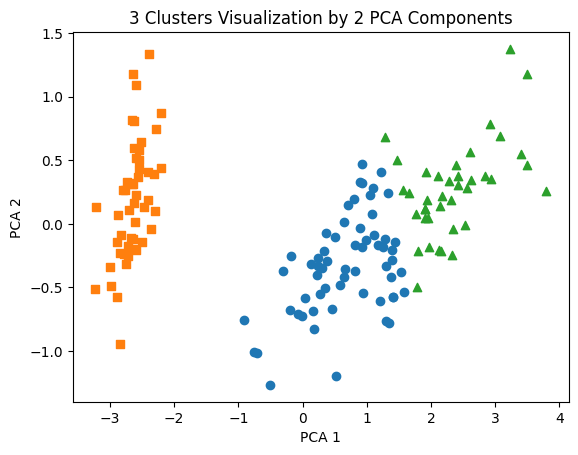

In [8]:
## 군집 값이 0, 1, 2인 경우마다 별도의 인덱스로 추출한다
marker0_ind = irisDF[irisDF['cluster']==0].index
marker1_ind = irisDF[irisDF['cluster']==1].index
marker2_ind = irisDF[irisDF['cluster']==2].index

## 군집 값 0, 1, 2에 해당하는 인덱스로 각 군집 레벨의 pca_x, pca_y 값을 추출한다. 이 때, 각 군집별로 o, s, ^로 마커 표시한다
plt.scatter(x=irisDF.loc[marker0_ind, 'pca_x'], y=irisDF.loc[marker0_ind, 'pca_y'], marker='o')
plt.scatter(x=irisDF.loc[marker1_ind, 'pca_x'], y=irisDF.loc[marker1_ind, 'pca_y'], marker='s')
plt.scatter(x=irisDF.loc[marker2_ind, 'pca_x'], y=irisDF.loc[marker2_ind, 'pca_y'], marker='^')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('3 Clusters Visualization by 2 PCA Components')
plt.show()

Cluster 1은 명확히 다른 군집과 잘 분리되어 있다. Cluster 0과 Cluster 2는 상당 수준 분리되어 있으나 Cluster 1만큼 명확하게 분리되어 있는 것은 아니다.

### 군집화 알고리즘 테스트를 위한 데이터 생성


*   사이킷런은 다양한 유형의 군집화 알고리즘을 테스트해보기 위한 간단한 데이터 생성기를 제공한다. 대표적으로 make_blobs()와 make_classification() API가 있는데, 두 API는 비슷하게 여러 개의 클래스에 해당하는 데이터 세트를 만들고 하나의 클래스에 여러 개의 군집이 분포될 수 있게 데이터를 생성할 수 있다. 둘 중에 어떤 것을 선택하는 큰 차이는 없지만, make_blobs()는 개별 군집의 중심점과 표준편차 제어 기능이 추가되어 있고, make_classification()은 노이즈를 포함한 데이터를 만드는 데 유용하게 사용할 수 있다. 둘 다 분류 용도로도 테스트 데이터 생성이 가능하다. 이 외에 make_circle(), make_moon() API는 중심 기반의 군집화로 해결하기 어려운 데이터 세트를 만드는 데 사용된다.
*   make_blobs()를 호출하면 피처 데이터 세트와 타깃 데이터 세트가 튜플로 반환된다 make_blobs()의 호출 파라미터는 n_samples(생성할 총 데이터의 개수, default=100), n_features(데이터의 피처 개수), centers(int값으로 설정하면 군집의 개수, ndarray 형태로 설정하면 개별 군집 중심점의 좌표), cluster_std(생성될 군집 데이터의 표준편차)이다.



In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
%matplotlib inline

X, y = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=0.8, random_state=0)
print(X.shape, y.shape)

## y target 값의 분포를 확인한다
unique, counts = np.unique(y, return_counts=True)
print(unique, counts)

(200, 2) (200,)
[0 1 2] [67 67 66]


In [10]:
import pandas as pd

## 데이터 가공을 편리하게 하기 위해 데이터 세트를 DataFrame으로 변경한다
clusterDF = pd.DataFrame(data=X, columns=['ftr1', 'ftr2'])
clusterDF['target'] = y
clusterDF.head(3)

,ftr1,ftr2,target
0,-1.692427,3.622025,2
1,0.697940,4.428867,0
2,1.100228,4.606317,0


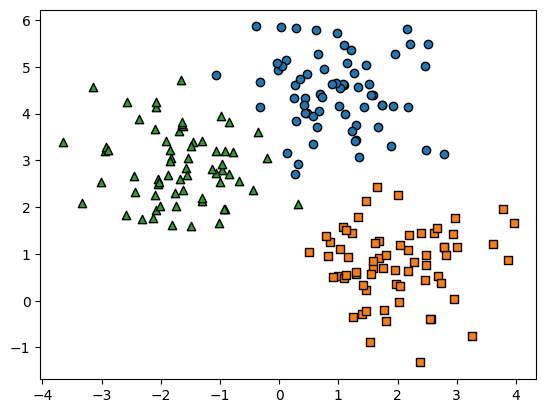

In [11]:
## make_blob()으로 만든 피처 데이터 세트가 어떤 군집화 분포를 가지고 만들어졌는지 확인한다
target_list = np.unique(y)

markers = ['o', 's', '^', 'P', 'D', 'H', 'x'] ## 각 타깃별 산점도의 마커 값
## 3개의 군집 영역으로 구분한 데이터 세트를 생성했으므로 target_list는 [0, 1, 2]이다
## target==0, target==1, target==2로 scatterplot을 marker별로 생성한다
for target in target_list:
  target_cluster = clusterDF[clusterDF['target']==target]
  plt.scatter(x=target_cluster['ftr1'], y=target_cluster['ftr2'], edgecolor='k', marker=markers[target])

plt.show()

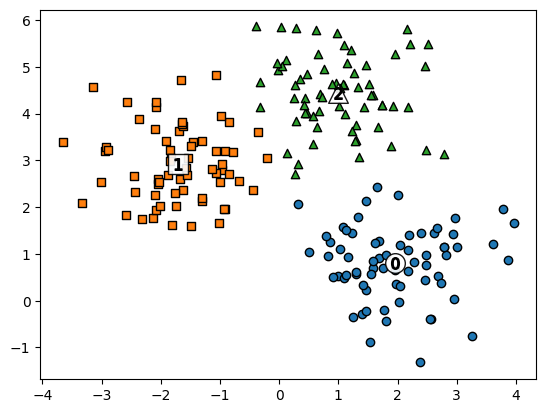

In [12]:
## 데이터 세트에 KMeans 군집화를 수행한 뒤에 군집별로 시각화한다
## KMeans 객체에 fit_predict(X)를 수행해 make_blobs()의 피처 데이터 세트인 X 데이터를 군집화한다
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=200, random_state=0)
cluster_labels = kmeans.fit_predict(X)
clusterDF['kmeans_label'] = cluster_labels

## cluster_centers_는 개별 클러스터의 중심 위치 좌표 시각화를 위해 추출한다
centers = kmeans.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers = ['o', 's', '^', 'P', 'D', 'H', 'x']

## 군집된 label 유형별로 iteration하면서 marker별로 scatterplot으로 시각화한다
for label in unique_labels:
  label_cluster = clusterDF[clusterDF['kmeans_label']==label]
  center_x_y = centers[label]
  plt.scatter(x=label_cluster['ftr1'], y=label_cluster['ftr2'], edgecolor='k', marker=markers[label])
  ## 군집별 중심 위치 좌표를 시각화한다
  plt.scatter(x=center_x_y[0], y=center_x_y[1], s=200, color='white', alpha=0.9, edgecolor='k', marker=markers[label])
  plt.scatter(x=center_x_y[0], y=center_x_y[1], s=70, color='k', edgecolor='k', marker='$%d$' % label)

plt.show()

In [13]:
print(clusterDF.groupby('target')['kmeans_label'].value_counts())

target  kmeans_label
0       2               66
        1                1
1       0               67
2       1               65
        0                1
Name: count, dtype: int64




*   이외에도 cluster_std의 값을 달리하며 데이터를 시각화하면, cluster_std가 작을수록 군집 중심에 데이터가 모여있고 클수록 데이터가 퍼져 있음을 알 수 있다.

## 군집 평가(Cluster Evaluation)


*   군집화가 효율적으로 잘 수행되었는지 평가할 수 있는 지표는 무엇일까? 비지도학습의 특성상 어떠한 지표라도 정확하게 성능을 평가하기는 어려우나, 그럼에도 불구하고 군집화의 성능을 평가하는 대표적인 방법으로 실루엣 분석을 이용한다.
### 실루엣 분석의 개요
*   실루엣 분석(silhouette analysis)은 각 군집 간의 거리가 얼마나 효율적으로 분리되어 있는지를 나타낸다. 효율적으로 잘 분리되었다는 것은 다른 군집과의 거리는 떨어져 있고 동일 군집끼리의 데이터는 서로 가깝게 잘 뭉쳐있다는 의미이다. 군집화가 잘 될수록 개별 군집은 비슷한 정도의 여유 공간을 가지고 떨어져 있을 것이다.

*   실루엣 분석은 개별 데이터가 가지는 군집화 지표인 실루엣 계수(silhouette coefficient)를 기반으로 한다. 이는 해당 데이터가 같은 군집 내의 데이터와 얼마나 가깝게 군집화되어 있고, 다른 군집에 있는 데이터와는 얼마나 멀리 분리되어 있는지를 나타내는 지표이다. 특정 데이터 포인트의 실루엣 계수 값은 해당 데이터 포인트와 같은 군집 내에 있는 다른 데이터 포인트와의 거리를 평균한 값 a(i), 해당 데이터 포이트가 속하지 않은 군집 중 가장 가까운 군집과의 평균 거리 b(i)를 기반으로 계산된다. 두 군집 간의 거리가 얼마나 떨어져 있는가의 값은 b(i) - a(i)이며, 이 값을 정규화하기 위해 Max(a(i), b(i)) 값으로 나눈다. 따라서 i번째 데이터 포인트의 실루엣 계수 값 s(i) = (b(i) - a(i)) / max(a(i), b(i))이다. 실루엣 계수는 -1에서 1 사이의 값을 가지며, 1로 가까워질수록 근처의 군집과 더 멀리 떨어져있다는 것이고 0에 가까울수록 근처의 군집과 가까워진다는 것이다. - 값은 아예 다른 군집에 데이터 포인트가 할당됐음을 뜻한다.
*   좋은 군집화가 되려면 첫째로 전체 실루엣 계수의 평균값, 즉 사이킷런의 silhouette_score() 값은 0~1 사이의 값을 가지며 1에 가까울수록 좋다. 둘째로 전체 실루엣 계수의 평균값과 더불어 개별 군집의 평균값의 편차가 크지 않아야 한다. 즉, 실루엣 계수 평균값이 전체 실루엣 계수의 평균값에서 크게 벗어나지 않는 것이 중요하다.

### 붓꽃 데이터 세트를 이용한 군집 평가







In [14]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
## 실루엣 분석 평가 지표 값을 구하기 위한 API를 추가한다
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
irisDF = pd.DataFrame(data=iris.data, columns=feature_names)
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, random_state=0).fit(irisDF)
irisDF['cluster'] = kmeans.labels_

## iris의 모든 개별 데이터에 실루엣 계수 값을 구한다
score_samples = silhouette_samples(iris.data, irisDF['cluster'])
print('silhouette_samples() return 값의 shape:', score_samples.shape)

## irisDF에 실루엣 계수 칼럼을 추가한다
irisDF['silhouette_coeff'] = score_samples

## 실루엣 계수 값의 평균을 계산한다
average_score = silhouette_score(iris.data, irisDF['cluster'])
print('붓꽃 데이터 세트 Silhouette Analysis Score: {0:.3f}'.format(average_score))
irisDF.head(3)

silhouette_samples() return 값의 shape: (150,)
붓꽃 데이터 세트 Silhouette Analysis Score: 0.551


,sepal_length,sepal_width,petal_length,petal_width,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,1,0.852582
1,4.9,3.0,1.4,0.2,1,0.814916
2,4.7,3.2,1.3,0.2,1,0.828797


In [15]:
## 군집별 평균 실루엣 계수 값을 확인한다
irisDF.groupby('cluster')['silhouette_coeff'].mean()

,silhouette_coeff
cluster,
0,0.422323
1,0.797604
2,0.436842


### 군집별 평균 실루엣 계수의 시각화를 통한 군집 개수 최적화 방법



*   visualize_silhouette()은 내부 파라미터로 여러 개의 군집 개수를 리스트로 가지는 첫 번째 파라미터와 피처 데이터 세트인 두 번째 파라미터를 가지고 있다. 이 함수는 군집 개수를 변화시키면서 K-평균 군집을 수행했을 때 개별 군집별 평균 실루엣 계수 값을 시각화해 군집의 개수를 정하는 데에 도움을 준다.



In [16]:
## visualize_silhouette([2, 3, 4, 5], X_features)

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

def visualize_silhouette(cluster_list, X):
  from matplotlib import pyplot as plt
  for n_clusters in cluster_list:
    fig, ax1 = plt.subplots(1)
    fig.set_size_inches(6, 4)
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])
    kmeans = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = kmeans.fit_predict(X)
    silhouette_vals = silhouette_samples(X, cluster_labels)
    silhouette_avg = silhouette_score(X, cluster_labels)
    y_lower = 10

    for i in range(n_clusters):
      ith_silhouette_vals = silhouette_vals[cluster_labels == i]
      ith_silhouette_vals.sort()
      size_cluster_i = ith_silhouette_vals.shape[0]
      y_upper = y_lower + size_cluster_i
      color = cm.nipy_spectral(float(i) / n_clusters)
      ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_silhouette_vals, facecolor=color, edgecolor=color, alpha=0.7)
      ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
      y_lower = y_upper + 10
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_title(f"Silhouette plot for {n_clusters} clusters")
    ax1.set_xlabel("Silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

  plt.tight_layout()
  plt.show()

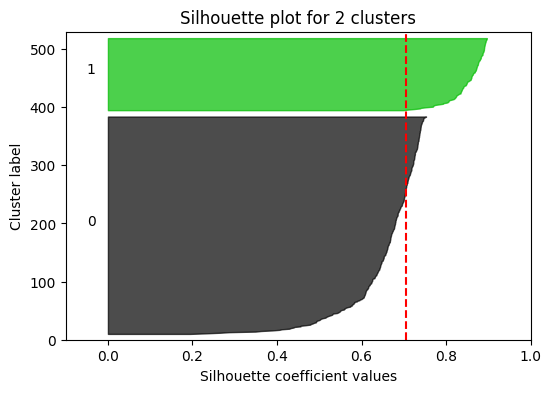

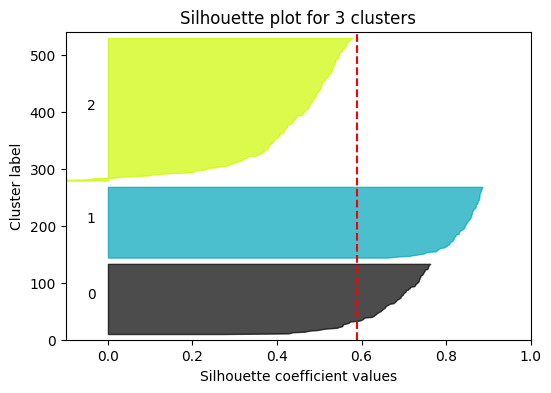

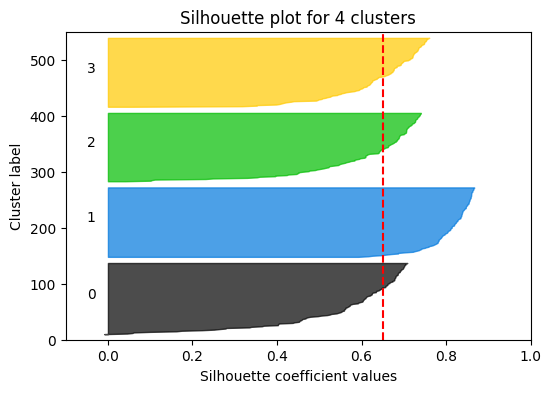

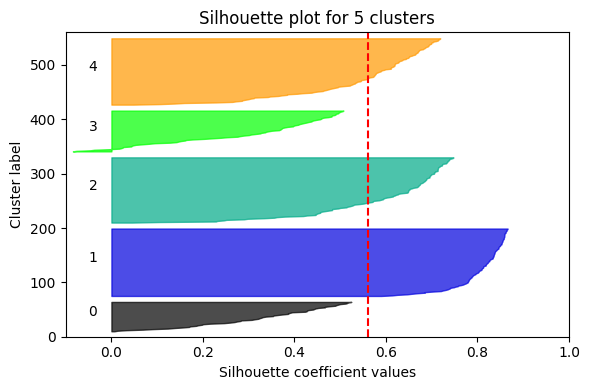

In [19]:
## make_blobs() 함수를 통해 4개 군집 중심의 500개 2차원 데이터 세ㅡ를 만들고 이를 K-평균으로 군집화할 때 2, 3, 4, 5개 중 최적의 군집 개수를 시각화로 알아본다
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=500, n_features=2, centers=4, cluster_std=1, center_box=(-10.0, 10.0), shuffle=True, random_state=1)
visualize_silhouette([2, 3, 4, 5], X)

4개의 군집일 때 가장 최적이 된다.

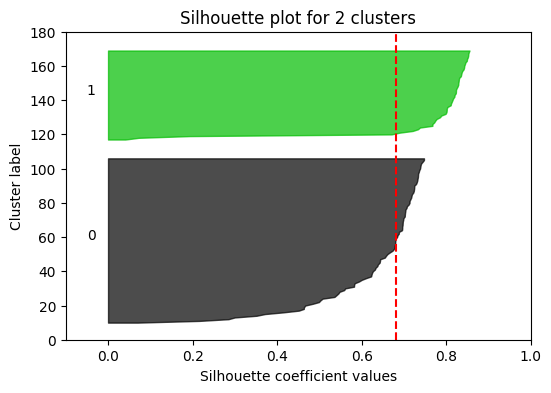

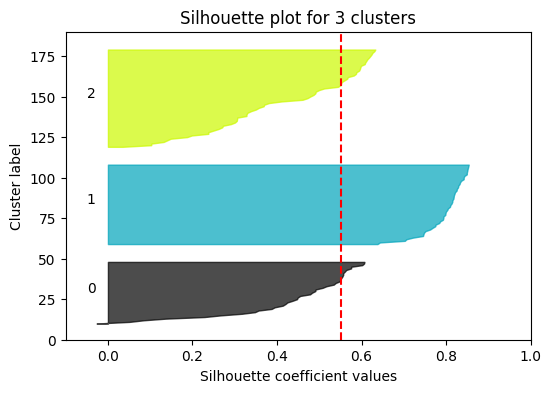

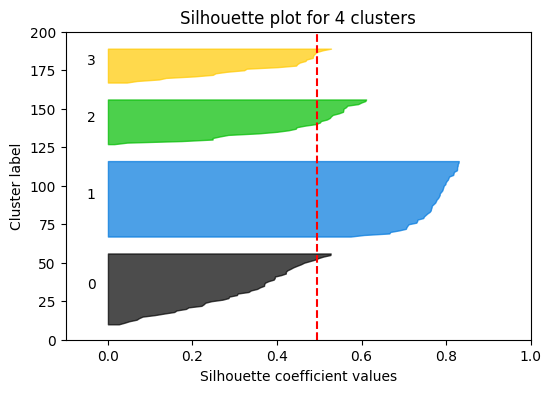

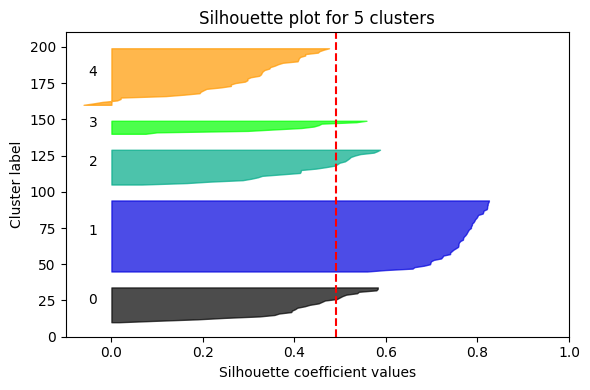

In [21]:
## 붓꽃 데이터를 이용해 K-평균 수행 시 최적의 군집 개수를 알아본다
from sklearn.datasets import load_iris
iris=load_iris()
visualize_silhouette([2, 3, 4, 5], iris.data)

군집 개수를 2개로 하는 것이 가장 좋아보인다.


*   실루엣 계수를 통한 K-평균 군집 평가 방법은 직관적으로 이해하기 쉬우나, 각 데이터별로 다른 데이터와의 거리를 반복적으로 계싼해야 하므로 데이터 양이 늘어나면 수행 시간이 크게 늘어난다. 특히 몇 만 건 이상의 데이터에 대해 사이킷런의 실루엣 계수 평가 API를 개인용 PC에서 수행할 경우 메모리 부족 등의 에러가 발생하기 쉽다. 이 경우 군집별로 임의의 데이터를 샘플링해 실루엣 계수를 평가하는 방안을 고민해야 한다.

## 평균 이동

## 평균 이동(Mean Shift)의 개요
*   평균 이동은 K-평균과 유사하게 중심을 군집의 중심으로 지속적으로 움직이면서 군집화를 수행한다. 하지만 K-평균이 중심에 소속된 데이터의 평균 거리 중심으로 이동하는 데 반해, 평균 이동은 중심을 데이터가 모여 있는 밀도가 가장 높은 곳으로 이동시킨다.

*   평균 이동 군집화는 데이터의 분포도를 이용해 군집 중심점을 찾는다. 군집 중심점은 데이터 포인트가 모여 있는 곳이라는 생각에서 착안한 것이며, 이를 위해 확률밀도함수를 이용한다. 가장 집중적으로 데이터가 모여 있어 PDF가 peak인 점을 군집 중심점으로 선정하며, 일반적으로 주어진 모델의 PDF를 찾기 위해 KDE(Kernel Density Estimation)를 이용한다.
*   평균 이동 군집화는 특정 데이터를 반경 내의 데이터 분포 확률 밀도가 가장 높은 곳으로 이동하기 위해, 주변 데이터와의 거리 값을 KDE 함수 값으로 입력한 뒤 그 반환 값을 현재 위치에서 업데이트하면서 이동하는 방식을 취한다. 이러한 방식을 전체 데이터에 반복적으로 적용하면서 데이터의 군집 중심점을 찾아낸다.



